In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:

iris = load_iris()

# Create DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add target column
df['species'] = iris.target

# Convert numeric target to flower names
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Display first 5 rows
print("First 5 Rows:")
print(df.head())


First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [4]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nNull Values:")
print(df.isnull().sum())



Dataset Shape:
(150, 5)

Column Names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.

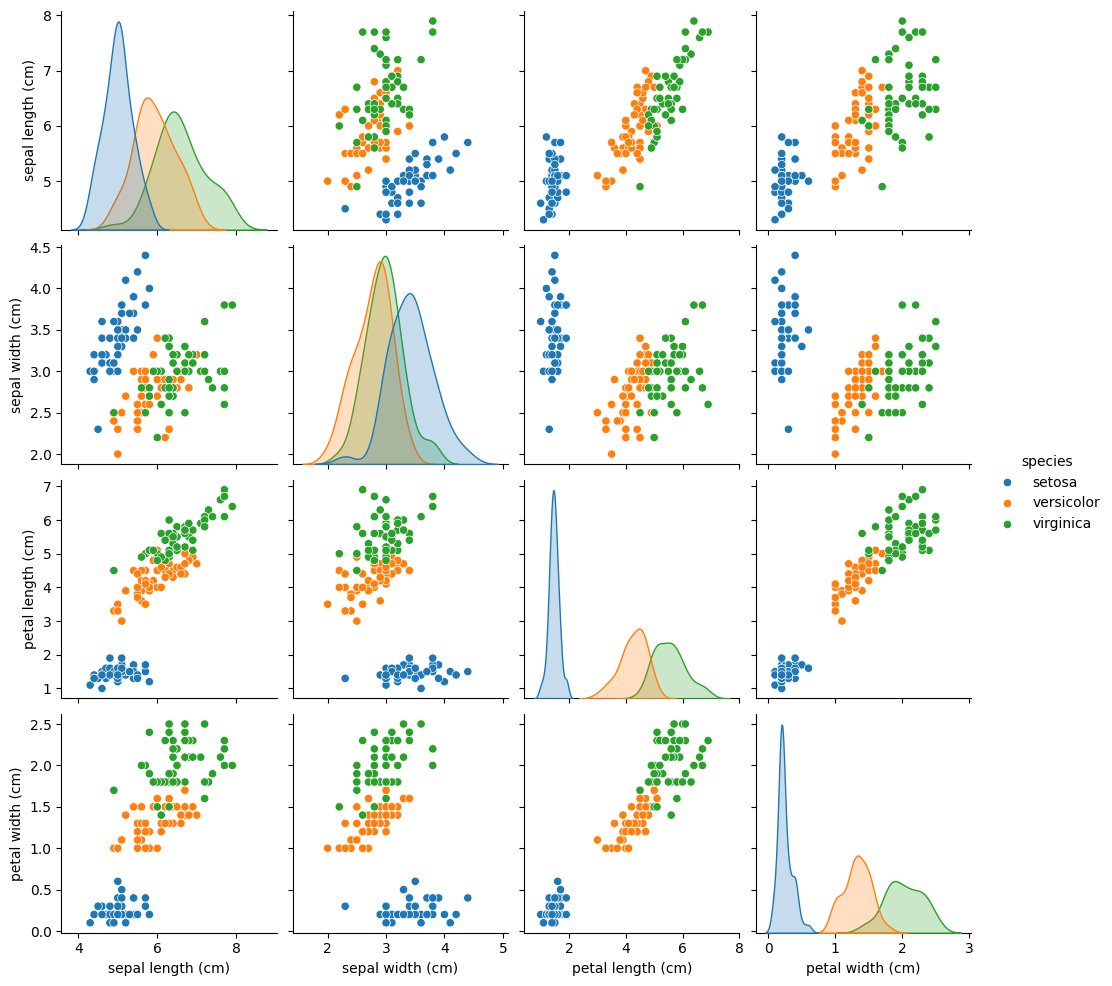

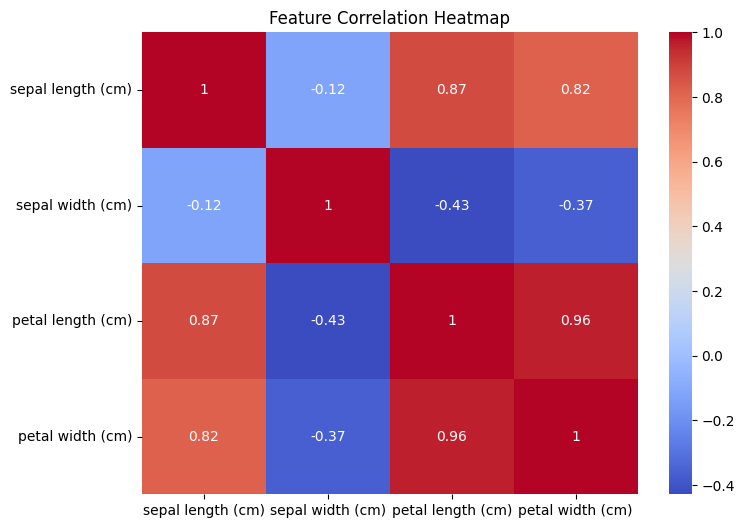

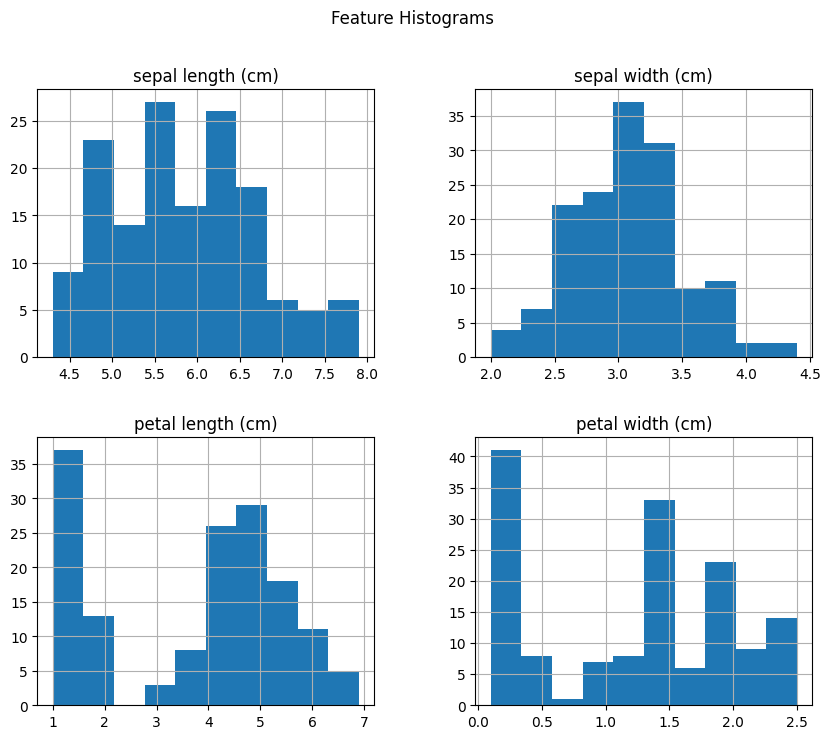

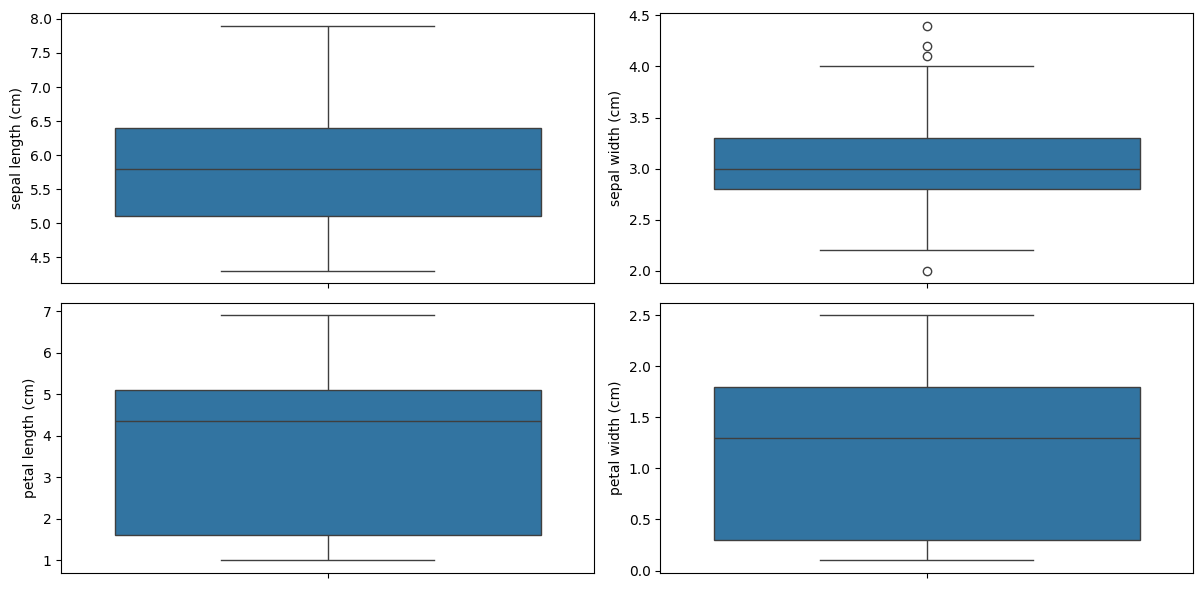

In [5]:

# Pairplot
sns.pairplot(df, hue='species')
plt.show()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Histograms
df.hist(figsize=(10,8))
plt.suptitle("Feature Histograms")
plt.show()

# Boxplots
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
sns.boxplot(y=df['sepal length (cm)'])

plt.subplot(2,2,2)
sns.boxplot(y=df['sepal width (cm)'])

plt.subplot(2,2,3)
sns.boxplot(y=df['petal length (cm)'])

plt.subplot(2,2,4)
sns.boxplot(y=df['petal width (cm)'])

plt.tight_layout()
plt.show()


In [6]:
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [7]:
lr_model = LogisticRegression(max_iter=200)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("\nLogistic Regression Accuracy:")
print(lr_accuracy)

# Classification Report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_predictions))



Logistic Regression Accuracy:
1.0

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("\nDecision Tree Accuracy:")
print(dt_accuracy)

# Classification Report
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_predictions))



Decision Tree Accuracy:
1.0

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [9]:

print("\nModel Comparison")
print("--------------------------")
print(f"Logistic Regression Accuracy : {lr_accuracy}")
print(f"Decision Tree Accuracy       : {dt_accuracy}")



Model Comparison
--------------------------
Logistic Regression Accuracy : 1.0
Decision Tree Accuracy       : 1.0


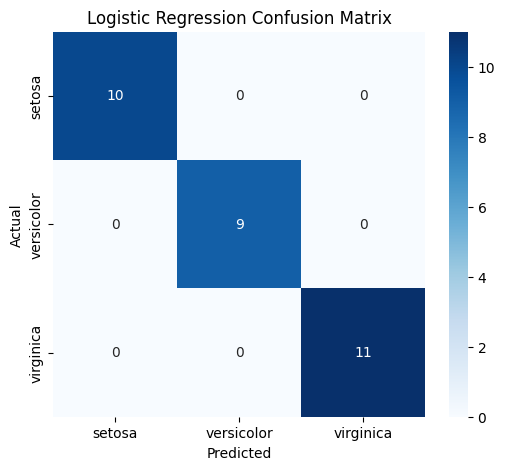

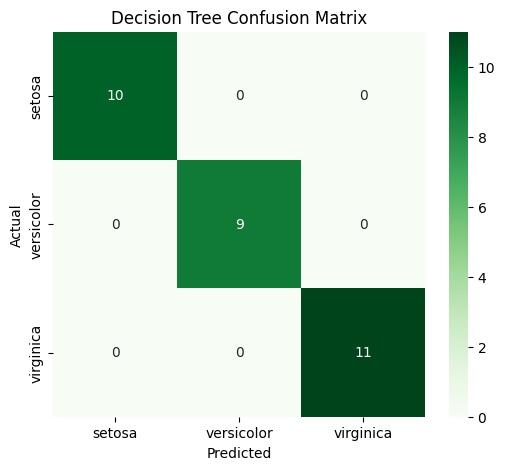

In [10]:

# Logistic Regression Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Decision Tree Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [11]:
print("\nMisclassification Interpretation:")
print("Off-diagonal values in confusion matrix represent incorrect predictions.")
print("If a flower species is predicted as another species, it appears outside the diagonal.")


Misclassification Interpretation:
Off-diagonal values in confusion matrix represent incorrect predictions.
If a flower species is predicted as another species, it appears outside the diagonal.


In [13]:

print("\nENTER FLOWER DETAILS")

sepal_length = float(input("Enter Sepal Length: "))
sepal_width = float(input("Enter Sepal Width: "))
petal_length = float(input("Enter Petal Length: "))
petal_width = float(input("Enter Petal Width: "))

new_data = [[
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
]]

# Predict using Logistic Regression
prediction = lr_model.predict(new_data)

flower_name = iris.target_names[prediction[0]]
print("\n==============================")
print(" Predicted Flower Species")
print("==============================")
print("Flower Name :", flower_name.upper())
print("==============================")


ENTER FLOWER DETAILS

 Predicted Flower Species
Flower Name : SETOSA
